# 03 — XAI Correlation: CREMA-D + CMU-MOSI

**Purpose:** Continue from the existing trained baseline checkpoints and existing MBS results. **No retraining.**

This notebook reconstructs the exact architectures used in the repository, downloads only the external datasets needed for XAI, aligns MBS by sample ID, computes encoder-level Integrated Gradients (20 steps, zero baseline), and calculates Pearson/Spearman correlation between MBS and XAI modality contribution.

CREMA-D raw media are not stored in GitHub, so this version automatically downloads the same public mirror used by the repository's original training notebook and preprocesses only the test samples needed for XAI.

CMU-MOSI uses the exact aligned `Processed/aligned_50.pkl` source used by the repository's baseline notebook.


In [1]:

# ============================================================
# CELL 1 — SETUP, REPOSITORY, DATA SOURCES
# ============================================================
!pip -q install gdown huggingface_hub librosa soundfile opencv-python-headless scipy scikit-learn pandas matplotlib

import os, sys, json, random, shutil, subprocess, zipfile, pickle, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import librosa
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from huggingface_hub import hf_hub_download

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ------------------------------------------------------------
# Repository
# ------------------------------------------------------------
REPO_URL = "https://github.com/Vaishnavi23457/DL_project.git"
REPO_DIR = Path("/content/DL_project")

if not REPO_DIR.exists():
    !git clone -q {REPO_URL} {REPO_DIR}

PROJECT_DIR = REPO_DIR / "modality_bias"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"

assert CHECKPOINT_DIR.exists(), CHECKPOINT_DIR
assert RESULTS_DIR.exists(), RESULTS_DIR

# ------------------------------------------------------------
# Existing checkpoints / MBS
# ------------------------------------------------------------
CREMA_CKPT = CHECKPOINT_DIR / "crema_d_baseline_best.pth"
CMU_CKPT   = CHECKPOINT_DIR / "cmu_mosi_baseline_best.pth"

CREMA_MBS = RESULTS_DIR / "mbs_per_sample.csv"
CREMA_MBS_FALLBACK = RESULTS_DIR / "crema_d_mbs_per_sample.csv"
CMU_MBS = RESULTS_DIR / "cmu_mosi" / "cmu_mosi_test_mbs.csv"

for p in [CREMA_CKPT, CMU_CKPT, CREMA_MBS, CMU_MBS]:
    print(p, "✓" if p.exists() else "MISSING")

# ------------------------------------------------------------
# CREMA-D raw-data source used by the repository
# ------------------------------------------------------------
CREMA_GDRIVE_ID = "1MPiFfSiEanCNu5HSon5Y2dGHsnpsUtRm"
CREMA_WORK = Path("/content/crema_d_xai_data")
CREMA_ARCHIVE = CREMA_WORK / "crema-d.zip"
CREMA_WORK.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CMU-MOSI aligned data source used by repository notebook
# ------------------------------------------------------------
CMU_REPO_ID = "tamb2203579/CMU-MOSI"
CMU_REMOTE_FILE = "Processed/aligned_50.pkl"
CMU_WORK = Path("/content/cmu_mosi_xai_data")
CMU_PKL = CMU_WORK / "Processed" / "aligned_50.pkl"
CMU_WORK.mkdir(parents=True, exist_ok=True)


Device: cpu
/content/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth ✓
/content/DL_project/modality_bias/checkpoints/cmu_mosi_baseline_best.pth ✓
/content/DL_project/modality_bias/results/mbs_per_sample.csv ✓
/content/DL_project/modality_bias/results/cmu_mosi/cmu_mosi_test_mbs.csv ✓


In [2]:

# ============================================================
# CELL 2 — EXACT CREMA-D MODEL + RAW DATA + TEST DATASET
# ============================================================

# ------------------------------------------------------------
# Exact architecture from modality_bias/notebooks/
# 01-setup-and-model-crema-d-mbs.ipynb
# ------------------------------------------------------------
class AudioEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class VisualEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        # weights=None is intentional: checkpoint supplies every parameter.
        base = models.resnet18(weights=None)
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        # [B,T,C,H,W]
        b,t,c,h,w = x.shape
        z = self.features(x.reshape(b*t,c,h,w)).flatten(1)
        z = z.reshape(b,t,-1).mean(1)
        return self.fc(z)


class CREMADBaseline(nn.Module):
    def __init__(self, num_classes=6, feature_dim=256):
        super().__init__()
        self.modalities = ["audio", "visual"]
        self.audio_encoder = AudioEncoder(feature_dim)
        self.visual_encoder = VisualEncoder(feature_dim)
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim*2, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
        self.audio_head = nn.Linear(feature_dim, num_classes)
        self.visual_head = nn.Linear(feature_dim, num_classes)

    def encode(self, inputs):
        return {
            "audio": self.audio_encoder(inputs["audio"]),
            "visual": self.visual_encoder(inputs["visual"])
        }

    def unimodal_logits(self, features):
        return {
            "audio": self.audio_head(features["audio"]),
            "visual": self.visual_head(features["visual"])
        }

    def forward(self, audio, visual):
        a = self.audio_encoder(audio)
        v = self.visual_encoder(visual)
        return self.fusion(torch.cat([a, v], dim=1))


# ------------------------------------------------------------
# Load teammate checkpoint
# ------------------------------------------------------------
ckpt = torch.load(CREMA_CKPT, map_location="cpu", weights_only=False)
crema_model = CREMADBaseline(num_classes=6).to(DEVICE)
crema_model.load_state_dict(ckpt["model_state_dict"], strict=True)
crema_model.eval()

print("✓ CREMA-D checkpoint loaded")
print("Checkpoint epoch:", ckpt.get("epoch"))
print("Validation macro-F1:", ckpt.get("val_macro_f1"))


# ------------------------------------------------------------
# Download CREMA-D raw media automatically
# ------------------------------------------------------------
if not (CREMA_WORK / "CREMA-D" / "AudioWAV").exists():
    print("Downloading CREMA-D raw audiovisual data...")
    if not CREMA_ARCHIVE.exists():
        subprocess.run(
            ["gdown", "--id", CREMA_GDRIVE_ID, "-O", str(CREMA_ARCHIVE)],
            check=True
        )

    print("Extracting...")
    subprocess.run(
        ["unzip", "-q", "-o", str(CREMA_ARCHIVE), "-d", str(CREMA_WORK)],
        check=True
    )

# Find AudioWAV/VideoFlash recursively because the archive root can vary.
audio_dirs = list(CREMA_WORK.rglob("AudioWAV"))
video_dirs = list(CREMA_WORK.rglob("VideoFlash"))

if not audio_dirs or not video_dirs:
    raise RuntimeError(
        "CREMA-D download/extraction completed but AudioWAV/VideoFlash "
        "could not be found."
    )

AUDIO_DIR = audio_dirs[0]
VIDEO_DIR = video_dirs[0]
RAW_ROOT = AUDIO_DIR.parent

print("CREMA raw root:", RAW_ROOT)
print("Audio:", AUDIO_DIR)
print("Video:", VIDEO_DIR)


# ------------------------------------------------------------
# Reconstruct the SAME speaker-independent split used by repo
# ------------------------------------------------------------
TEST_ACTORS = set(range(1083, 1092))
LABEL_MAP = {"ANG":0, "DIS":1, "FEA":2, "HAP":3, "NEU":4, "SAD":5}

rows = []
for vf in sorted(VIDEO_DIR.glob("*.flv")):
    stem = vf.stem
    parts = stem.split("_")
    if len(parts) < 3 or parts[2] not in LABEL_MAP:
        continue

    actor = int(parts[0])
    if actor not in TEST_ACTORS:
        continue

    wav = AUDIO_DIR / f"{stem}.wav"
    if wav.exists():
        rows.append({
            "id": stem,
            "audio": str(wav),
            "video": str(vf),
            "actor": actor,
            "label": LABEL_MAP[parts[2]]
        })

crema_test_meta = pd.DataFrame(rows)

if len(crema_test_meta) != 1065:
    print("WARNING: reconstructed test count =", len(crema_test_meta))
else:
    print("✓ CREMA-D test samples:", len(crema_test_meta))


# ------------------------------------------------------------
# Exact preprocessing from repository training notebook
# ------------------------------------------------------------
AUDIO_SR = 16000
AUDIO_SECONDS = 4
N_MELS = 64
NUM_FRAMES = 8
IMAGE_SIZE = 224

imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

def load_audio_exact(path):
    y, sr = librosa.load(path, sr=AUDIO_SR, mono=True)
    target_len = AUDIO_SR * AUDIO_SECONDS

    if len(y) < target_len:
        y = np.pad(y, (0, target_len-len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=AUDIO_SR, n_mels=N_MELS,
        n_fft=1024, hop_length=256
    )
    mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)

    return torch.from_numpy(mel).unsqueeze(0).float()


def load_video_exact(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        raise RuntimeError(f"Could not read video: {path}")

    indices = np.linspace(
        0, max(total-1, 0), NUM_FRAMES
    ).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
        frames.append(frame)

    cap.release()

    if not frames:
        raise RuntimeError(f"No frames decoded: {path}")

    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1].copy())

    arr = np.stack(frames[:NUM_FRAMES]).astype(np.float32) / 255.0
    x = torch.from_numpy(arr).permute(0,3,1,2)

    x = torch.stack([imagenet_norm(frame) for frame in x])
    return x.float()


class CREMATestDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        return {
            "audio": load_audio_exact(r.audio),
            "visual": load_video_exact(r.video),
            "label": int(r.label),
            "id": r.id
        }


crema_test_ds = CREMATestDataset(crema_test_meta)


✓ CREMA-D checkpoint loaded
Checkpoint epoch: 15
Validation macro-F1: 0.6673682928796881
Extracting...
CREMA raw root: /content/crema_d_xai_data/datasets/CREMA-D
Audio: /content/crema_d_xai_data/datasets/CREMA-D/AudioWAV
Video: /content/crema_d_xai_data/datasets/CREMA-D/VideoFlash


In [10]:
# ============================================================
# CREMA-D — USE AUTHORITATIVE TEST SPLIT
# ============================================================

from pathlib import Path
import pandas as pd
import os

REPO_ROOT = Path("/content/DL_project")
RESULTS_DIR = REPO_ROOT / "modality_bias" / "results"

METADATA_PATH = RESULTS_DIR / "crema_d_metadata.csv"

print("Metadata:", METADATA_PATH)

assert METADATA_PATH.exists(), (
    f"CREMA-D metadata not found: {METADATA_PATH}"
)

crema_metadata = pd.read_csv(METADATA_PATH)

print("Metadata columns:")
print(crema_metadata.columns.tolist())

print("\nSplit counts:")
print(crema_metadata["split"].value_counts())

Metadata: /content/DL_project/modality_bias/results/crema_d_metadata.csv
Metadata columns:
['id', 'video', 'audio', 'speaker', 'label', 'emotion', 'split']

Split counts:
split
train    5226
val      1146
test     1065
Name: count, dtype: int64


In [11]:
# ============================================================
# GET EXACT TEST SPLIT FROM METADATA
# ============================================================

crema_test_meta = (
    crema_metadata[
        crema_metadata["split"].astype(str).str.lower().eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)

print("CREMA-D test samples from metadata:", len(crema_test_meta))

assert len(crema_test_meta) == 1065, (
    f"Expected 1065 CREMA-D test samples, "
    f"but metadata contains {len(crema_test_meta)}"
)

CREMA-D test samples from metadata: 1065


In [12]:
# ============================================================
# IDENTIFY SAMPLE-ID COLUMN
# ============================================================

possible_id_cols = [
    "id",
    "sample_id",
    "clip_id",
    "filename",
    "file_id"
]

id_col = next(
    (c for c in possible_id_cols if c in crema_test_meta.columns),
    None
)

if id_col is None:
    raise ValueError(
        f"Could not identify CREMA-D ID column. "
        f"Available columns: {crema_test_meta.columns.tolist()}"
    )

print("Using CREMA-D ID column:", id_col)

crema_test_meta["id"] = (
    crema_test_meta[id_col]
    .astype(str)
    .str.replace(r"\.(wav|mp4|flv)$", "", regex=True)
)

print("Unique test IDs:", crema_test_meta["id"].nunique())

assert crema_test_meta["id"].is_unique, \
    "CREMA-D test IDs are not unique."

Using CREMA-D ID column: id
Unique test IDs: 1065


In [14]:
# ============================================================
# BUILD RAW MEDIA MAPS
# ============================================================

CREMA_ROOT = Path("/content/crema_d_xai_data/datasets/CREMA-D")
AUDIO_ROOT = CREMA_ROOT / "AudioWAV"
VIDEO_ROOT = CREMA_ROOT / "VideoFlash"

assert AUDIO_ROOT.exists(), f"Audio folder missing: {AUDIO_ROOT}"
assert VIDEO_ROOT.exists(), f"Video folder missing: {VIDEO_ROOT}"

def canonical_stem(path):
    """
    Convert a raw CREMA-D filename into the canonical sample ID.
    Example:
        1001_DFA_ANG_XX.wav -> 1001_DFA_ANG_XX
    """
    return Path(path).stem

audio_map = {
    canonical_stem(p): str(p)
    for p in AUDIO_ROOT.rglob("*")
    if p.is_file()
}

video_map = {
    canonical_stem(p): str(p)
    for p in VIDEO_ROOT.rglob("*")
    if p.is_file()
}

print("Audio files found:", len(audio_map))
print("Video files found:", len(video_map))

Audio files found: 7437
Video files found: 7437


In [15]:
# ============================================================
# MAP TEST IDS → AUDIO + VIDEO
# ============================================================

crema_test_meta["audio_path"] = (
    crema_test_meta["id"].map(audio_map)
)

crema_test_meta["video_path"] = (
    crema_test_meta["id"].map(video_map)
)

missing_audio = crema_test_meta[
    crema_test_meta["audio_path"].isna()
]

missing_video = crema_test_meta[
    crema_test_meta["video_path"].isna()
]

print("Missing audio:", len(missing_audio))
print("Missing video:", len(missing_video))

if len(missing_audio) > 0:
    print(
        "Missing audio examples:",
        missing_audio["id"].head(10).tolist()
    )

if len(missing_video) > 0:
    print(
        "Missing video examples:",
        missing_video["id"].head(10).tolist()
    )

assert len(missing_audio) == 0, \
    "Some metadata test IDs have no corresponding audio file."

assert len(missing_video) == 0, \
    "Some metadata test IDs have no corresponding video file."

Missing audio: 0
Missing video: 0


In [16]:
# ============================================================
# FINAL CREMA-D TEST-SET VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("CREMA-D TEST SET VALIDATION")
print("=" * 60)

print("Metadata test samples :", len(crema_test_meta))
print("Unique test IDs       :", crema_test_meta["id"].nunique())
print("Audio paths           :", crema_test_meta["audio_path"].notna().sum())
print("Video paths           :", crema_test_meta["video_path"].notna().sum())

assert len(crema_test_meta) == 1065
assert crema_test_meta["id"].nunique() == 1065
assert crema_test_meta["audio_path"].notna().all()
assert crema_test_meta["video_path"].notna().all()

print("\n✓ CREMA-D exact test split = 1065")
print("✓ All test IDs unique")
print("✓ All audio files found")
print("✓ All video files found")


CREMA-D TEST SET VALIDATION
Metadata test samples : 1065
Unique test IDs       : 1065
Audio paths           : 1065
Video paths           : 1065

✓ CREMA-D exact test split = 1065
✓ All test IDs unique
✓ All audio files found
✓ All video files found


In [19]:
# ============================================================
# METADATA-DRIVEN CREMA-D XAI DATASET
# ============================================================

from torch.utils.data import Dataset
import torch
import librosa
import cv2
import numpy as np

class CREMAXAIDataset(Dataset):

    def __init__(self, metadata):
        self.meta = metadata.reset_index(drop=True)

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):

        row = self.meta.iloc[idx]

        sample_id = row["id"]

        # -------------------------
        # AUDIO
        # -------------------------
        audio, sr = librosa.load(
            row["audio_path"],
            sr=16000,
            mono=True
        )

        target_len = 16000 * 4

        if len(audio) < target_len:
            audio = np.pad(
                audio,
                (0, target_len - len(audio))
            )
        else:
            audio = audio[:target_len]

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=16000,
            n_fft=1024,
            hop_length=256,
            n_mels=64
        )

        mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        mel = (
            mel - mel.mean()
        ) / (
            mel.std() + 1e-6
        )

        audio_tensor = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        # -------------------------
        # VIDEO
        # -------------------------
        cap = cv2.VideoCapture(
            row["video_path"]
        )

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        n_frames = 8

        if total_frames > 0:
            indices = np.linspace(
                0,
                total_frames - 1,
                n_frames
            ).astype(int)
        else:
            indices = np.zeros(
                n_frames,
                dtype=int
            )

        frames = []

        for frame_idx in indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_idx)
            )

            ok, frame = cap.read()

            if not ok:
                continue

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (224, 224)
            )

            frame = frame.astype(
                np.float32
            ) / 255.0

            frames.append(frame)

        cap.release()

        while len(frames) < n_frames:

            if len(frames) > 0:
                frames.append(frames[-1].copy())
            else:
                frames.append(
                    np.zeros(
                        (224, 224, 3),
                        dtype=np.float32
                    )
                )

        frames = np.stack(
            frames[:n_frames]
        )

        # ImageNet normalization
        mean = np.array(
            [0.485, 0.456, 0.406],
            dtype=np.float32
        )

        std = np.array(
            [0.229, 0.224, 0.225],
            dtype=np.float32
        )

        frames = (
            frames - mean
        ) / std

        video_tensor = torch.tensor(
            frames,
            dtype=torch.float32
        ).permute(0, 3, 1, 2)

        # -------------------------
        # LABEL
        # -------------------------
        label = int(row["label"])

        return {
            "id": sample_id,
            "audio": audio_tensor,
            "visual": video_tensor,
            "label": label
        }

In [20]:
crema_test_ds = CREMAXAIDataset(
    crema_test_meta
)

print(
    "CREMA-D XAI test dataset:",
    len(crema_test_ds)
)

assert len(crema_test_ds) == 1065

CREMA-D XAI test dataset: 1065


In [21]:
# ============================================================
# CREMA-D MBS — EXACT ID ALIGNMENT
# ============================================================

mbs = pd.read_csv(
    "/content/DL_project/modality_bias/results/mbs_per_sample.csv"
)

print("MBS columns:")
print(mbs.columns.tolist())

# Keep only required columns
mbs = mbs.copy()

mbs["id"] = mbs["id"].astype(str)
crema_test_meta["id"] = crema_test_meta["id"].astype(str)

# Only test samples
crema_test_ids = set(
    crema_test_meta["id"]
)

crema_mbs = mbs[
    mbs["id"].isin(crema_test_ids)
].copy()

print(
    "CREMA-D MBS test samples:",
    len(crema_mbs)
)

assert len(crema_mbs) == 1065
assert crema_mbs["id"].nunique() == 1065

MBS columns:
['id', 'mbs_audio', 'mbs_visual']
CREMA-D MBS test samples: 1065


In [22]:
metadata_ids = set(
    crema_test_meta["id"]
)

mbs_ids = set(
    crema_mbs["id"]
)

print(
    "Metadata-only IDs:",
    len(metadata_ids - mbs_ids)
)

print(
    "MBS-only IDs:",
    len(mbs_ids - metadata_ids)
)

assert metadata_ids == mbs_ids, \
    "CREMA-D metadata and MBS IDs do not match."

Metadata-only IDs: 0
MBS-only IDs: 0


In [23]:

# ============================================================
# CELL 2 — EXACT CREMA-D MODEL + RAW DATA + TEST DATASET
# ============================================================

# ------------------------------------------------------------
# Exact architecture from modality_bias/notebooks/
# 01-setup-and-model-crema-d-mbs.ipynb
# ------------------------------------------------------------
class AudioEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class VisualEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        # weights=None is intentional: checkpoint supplies every parameter.
        base = models.resnet18(weights=None)
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        # [B,T,C,H,W]
        b,t,c,h,w = x.shape
        z = self.features(x.reshape(b*t,c,h,w)).flatten(1)
        z = z.reshape(b,t,-1).mean(1)
        return self.fc(z)


class CREMADBaseline(nn.Module):
    def __init__(self, num_classes=6, feature_dim=256):
        super().__init__()
        self.modalities = ["audio", "visual"]
        self.audio_encoder = AudioEncoder(feature_dim)
        self.visual_encoder = VisualEncoder(feature_dim)
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim*2, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
        self.audio_head = nn.Linear(feature_dim, num_classes)
        self.visual_head = nn.Linear(feature_dim, num_classes)

    def encode(self, inputs):
        return {
            "audio": self.audio_encoder(inputs["audio"]),
            "visual": self.visual_encoder(inputs["visual"])
        }

    def unimodal_logits(self, features):
        return {
            "audio": self.audio_head(features["audio"]),
            "visual": self.visual_head(features["visual"])
        }

    def forward(self, audio, visual):
        a = self.audio_encoder(audio)
        v = self.visual_encoder(visual)
        return self.fusion(torch.cat([a, v], dim=1))


# ------------------------------------------------------------
# Load teammate checkpoint
# ------------------------------------------------------------
ckpt = torch.load(CREMA_CKPT, map_location="cpu", weights_only=False)
crema_model = CREMADBaseline(num_classes=6).to(DEVICE)
crema_model.load_state_dict(ckpt["model_state_dict"], strict=True)
crema_model.eval()

print("✓ CREMA-D checkpoint loaded")
print("Checkpoint epoch:", ckpt.get("epoch"))
print("Validation macro-F1:", ckpt.get("val_macro_f1"))


# ------------------------------------------------------------
# Download CREMA-D raw media automatically
# ------------------------------------------------------------
if not (CREMA_WORK / "CREMA-D" / "AudioWAV").exists():
    print("Downloading CREMA-D raw audiovisual data...")
    if not CREMA_ARCHIVE.exists():
        subprocess.run(
            ["gdown", "--id", CREMA_GDRIVE_ID, "-O", str(CREMA_ARCHIVE)],
            check=True
        )

    print("Extracting...")
    subprocess.run(
        ["unzip", "-q", "-o", str(CREMA_ARCHIVE), "-d", str(CREMA_WORK)],
        check=True
    )

# Find AudioWAV/VideoFlash recursively because the archive root can vary.
audio_dirs = list(CREMA_WORK.rglob("AudioWAV"))
video_dirs = list(CREMA_WORK.rglob("VideoFlash"))

if not audio_dirs or not video_dirs:
    raise RuntimeError(
        "CREMA-D download/extraction completed but AudioWAV/VideoFlash "
        "could not be found."
    )

AUDIO_DIR = audio_dirs[0]
VIDEO_DIR = video_dirs[0]
RAW_ROOT = AUDIO_DIR.parent

print("CREMA raw root:", RAW_ROOT)
print("Audio:", AUDIO_DIR)
print("Video:", VIDEO_DIR)


# ------------------------------------------------------------
# ------------------------------------------------------------
# IMPORTANT: use the EXACT split saved by the repository.
# The CREMA-D repo did NOT use actor IDs 1083-1091 for the
# checkpoint whose MBS is in results/mbs_per_sample.csv.
# It created a deterministic 70/15/15 speaker split with seed 42
# and saved the resulting sample membership in crema_d_metadata.csv.
# ------------------------------------------------------------
metadata_path = RESULTS_DIR / "crema_d_metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError(
        f"Required repository metadata not found: {metadata_path}"
    )

repo_meta = pd.read_csv(metadata_path)
required_meta = {"id", "video", "audio", "speaker", "label", "emotion", "split"}
if not required_meta.issubset(repo_meta.columns):
    raise ValueError(
        f"CREMA-D metadata is missing columns: "
        f"{required_meta - set(repo_meta.columns)}"
    )

# We only need the test rows. Their stored IDs are the authoritative
# sample list for the trained baseline and its MBS file.
test_ids = repo_meta.loc[repo_meta["split"] == "test", "id"].astype(str).tolist()

# Rebuild raw-media paths from those exact IDs.
crema_test_meta = repo_meta.loc[
    repo_meta["split"] == "test",
    ["id", "speaker", "label", "emotion"]
].copy()
crema_test_meta["id"] = crema_test_meta["id"].astype(str)
crema_test_meta["label"] = crema_test_meta["label"].astype(int)
crema_test_meta["audio"] = crema_test_meta["id"].map(
    lambda stem: str(AUDIO_DIR / f"{stem}.wav")
)
crema_test_meta["video"] = crema_test_meta["id"].map(
    lambda stem: str(VIDEO_DIR / f"{stem}.flv")
)

missing_audio = crema_test_meta.loc[
    ~crema_test_meta["audio"].map(os.path.exists), "id"
].tolist()
missing_video = crema_test_meta.loc[
    ~crema_test_meta["video"].map(os.path.exists), "id"
].tolist()

if missing_audio or missing_video:
    raise FileNotFoundError(
        f"Missing CREMA-D test media: "
        f"audio={missing_audio[:5]}, video={missing_video[:5]}"
    )

print("✓ Using repository's exact CREMA-D split from crema_d_metadata.csv")
print("  test samples:", len(crema_test_meta))
print("  test speakers:", crema_test_meta["speaker"].nunique())
print("  speakers:", sorted(crema_test_meta["speaker"].astype(int).unique().tolist()))

# This should be exactly 1,065 for the teammate's baseline.
if len(crema_test_meta) != 1065:
    raise RuntimeError(
        f"Expected 1065 CREMA-D test samples from the repository metadata, "
        f"got {len(crema_test_meta)}. Do not continue with XAI."
    )

# ------------------------------------------------------------
# Exact preprocessing from repository training notebook
# ------------------------------------------------------------
AUDIO_SR = 16000
AUDIO_SECONDS = 4
N_MELS = 64
NUM_FRAMES = 8
IMAGE_SIZE = 224

imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

def load_audio_exact(path):
    y, sr = librosa.load(path, sr=AUDIO_SR, mono=True)
    target_len = AUDIO_SR * AUDIO_SECONDS

    if len(y) < target_len:
        y = np.pad(y, (0, target_len-len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=AUDIO_SR, n_mels=N_MELS,
        n_fft=1024, hop_length=256
    )
    mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)

    return torch.from_numpy(mel).unsqueeze(0).float()


def load_video_exact(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        raise RuntimeError(f"Could not read video: {path}")

    indices = np.linspace(
        0, max(total-1, 0), NUM_FRAMES
    ).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
        frames.append(frame)

    cap.release()

    if not frames:
        raise RuntimeError(f"No frames decoded: {path}")

    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1].copy())

    arr = np.stack(frames[:NUM_FRAMES]).astype(np.float32) / 255.0
    x = torch.from_numpy(arr).permute(0,3,1,2)

    x = torch.stack([imagenet_norm(frame) for frame in x])
    return x.float()


class CREMATestDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        return {
            "audio": load_audio_exact(r.audio),
            "visual": load_video_exact(r.video),
            "label": int(r.label),
            "id": r.id
        }


crema_test_ds = CREMATestDataset(crema_test_meta)


✓ CREMA-D checkpoint loaded
Checkpoint epoch: 15
Validation macro-F1: 0.6673682928796881
Extracting...
CREMA raw root: /content/crema_d_xai_data/datasets/CREMA-D
Audio: /content/crema_d_xai_data/datasets/CREMA-D/AudioWAV
Video: /content/crema_d_xai_data/datasets/CREMA-D/VideoFlash
✓ Using repository's exact CREMA-D split from crema_d_metadata.csv
  test samples: 1065
  test speakers: 13
  speakers: [1002, 1003, 1015, 1021, 1022, 1024, 1052, 1053, 1061, 1072, 1075, 1083, 1085]


In [25]:
# ============================================================
# CELL 3 — CREMA-D XAI + MBS/XAI PER-SAMPLE RESULTS
# ============================================================

# ------------------------------------------------------------
# Encoder-level Integrated Gradients
# ------------------------------------------------------------
# We compute IG with respect to the 256-D modality embeddings.
# MBS remains completely independent of XAI.
# ------------------------------------------------------------

def integrated_gradients_fusion_crema(
    emb_dict,
    target_class,
    n_steps=20
):
    """
    Integrated Gradients for CREMA-D fusion output.

    Attribution is computed with respect to:
        audio embedding: 256-D
        visual embedding: 256-D

    Baseline:
        zero embedding

    Target:
        true class logit
    """

    names = ["audio", "visual"]

    base = {
        m: torch.zeros_like(emb_dict[m])
        for m in names
    }

    totals = {
        m: torch.zeros_like(emb_dict[m])
        for m in names
    }

    alphas = torch.linspace(
        0.0,
        1.0,
        n_steps,
        device=DEVICE
    )

    for alpha in alphas:

        interp = {}

        for m in names:
            interp[m] = (
                base[m]
                + alpha * (emb_dict[m] - base[m])
            ).detach().requires_grad_(True)

        # Fusion layer only.
        fused_logits = crema_model.fusion(
            torch.cat(
                [
                    interp["audio"],
                    interp["visual"]
                ],
                dim=1
            )
        )

        target_logit = fused_logits[:, target_class].sum()

        grads = torch.autograd.grad(
            target_logit,
            [
                interp["audio"],
                interp["visual"]
            ],
            retain_graph=False,
            create_graph=False
        )

        totals["audio"] += grads[0]
        totals["visual"] += grads[1]

    ig = {
        m: (
            emb_dict[m] - base[m]
        ) * totals[m] / n_steps
        for m in names
    }

    return ig


# ------------------------------------------------------------
# Prepare CREMA-D MBS in EXACT test-set order
# ------------------------------------------------------------

crema_test_order = crema_test_meta[
    ["id", "label"]
].copy()

crema_test_order["id"] = (
    crema_test_order["id"].astype(str)
)

crema_test_order["label"] = (
    crema_test_order["label"].astype(int)
)

crema_mbs["id"] = crema_mbs["id"].astype(str)

crema_ordered = crema_test_order.merge(
    crema_mbs[
        [
            "id",
            "mbs_audio",
            "mbs_visual"
        ]
    ],
    on="id",
    how="left",
    validate="one_to_one"
)

# Verify complete alignment
if crema_ordered[
    ["mbs_audio", "mbs_visual"]
].isna().any().any():

    raise ValueError(
        "CREMA-D MBS alignment contains missing values."
    )

assert len(crema_ordered) == 1065

print("✓ CREMA-D MBS aligned by sample ID")
print("CREMA-D samples for XAI:", len(crema_ordered))


# ------------------------------------------------------------
# Compute XAI
# ------------------------------------------------------------

crema_rows = []

for i in range(len(crema_test_ds)):

    sample = crema_test_ds[i]

    audio = (
        sample["audio"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    visual = (
        sample["visual"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    true_label = int(
        sample["label"]
    )

    sample_id = str(
        sample["id"]
    )

    # --------------------------------------------------------
    # Get modality embeddings
    # --------------------------------------------------------
    with torch.no_grad():

        embeddings = crema_model.encode(
            {
                "audio": audio,
                "visual": visual
            }
        )

        fused_logits = crema_model.fusion(
            torch.cat(
                [
                    embeddings["audio"],
                    embeddings["visual"]
                ],
                dim=1
            )
        )

        prediction = int(
            fused_logits.argmax(
                dim=1
            ).item()
        )

    # --------------------------------------------------------
    # Integrated Gradients
    # --------------------------------------------------------
    emb_for_ig = {
        m: embeddings[m].detach()
        for m in ["audio", "visual"]
    }

    ig = integrated_gradients_fusion_crema(
        emb_for_ig,
        target_class=true_label,
        n_steps=20
    )

    # --------------------------------------------------------
    # Attribution norms
    # --------------------------------------------------------
    audio_norm = float(
        torch.linalg.vector_norm(
            ig["audio"]
        ).item()
    )

    visual_norm = float(
        torch.linalg.vector_norm(
            ig["visual"]
        ).item()
    )

    denom = (
        audio_norm
        + visual_norm
    )

    # --------------------------------------------------------
    # Normalize to modality contribution shares
    # --------------------------------------------------------
    if denom <= 1e-12:

        xai_audio = 0.5
        xai_visual = 0.5

    else:

        xai_audio = (
            audio_norm / denom
        )

        xai_visual = (
            visual_norm / denom
        )

    crema_rows.append(
        {
            "id": sample_id,
            "true_label": true_label,

            "mbs_audio": float(
                crema_ordered.loc[
                    crema_ordered["id"] == sample_id,
                    "mbs_audio"
                ].iloc[0]
            ),

            "mbs_visual": float(
                crema_ordered.loc[
                    crema_ordered["id"] == sample_id,
                    "mbs_visual"
                ].iloc[0]
            ),

            "prediction": prediction,

            "ig_audio_norm": audio_norm,
            "ig_visual_norm": visual_norm,

            "xai_audio": xai_audio,
            "xai_visual": xai_visual
        }
    )

    # Progress
    if (i + 1) % 50 == 0:
        print(
            f"CREMA-D XAI progress: "
            f"{i + 1}/{len(crema_test_ds)}"
        )


# ------------------------------------------------------------
# Final CREMA-D XAI dataframe
# ------------------------------------------------------------

crema_result = pd.DataFrame(
    crema_rows
)

assert len(crema_result) == 1065

assert crema_result["id"].is_unique

assert np.allclose(
    crema_result["xai_audio"]
    + crema_result["xai_visual"],
    1.0,
    atol=1e-6
)

print()
print("✓ CREMA-D XAI completed:", len(crema_result))

print(
    "Mean XAI audio:",
    crema_result["xai_audio"].mean()
)

print(
    "Mean XAI visual:",
    crema_result["xai_visual"].mean()
)

print(
    "Mean MBS audio:",
    crema_result["mbs_audio"].mean()
)

print(
    "Mean MBS visual:",
    crema_result["mbs_visual"].mean()
)


# ------------------------------------------------------------
# Save CREMA-D per-sample XAI + MBS
# ------------------------------------------------------------

CREMA_XAI_CSV = (
    RESULTS_DIR /
    "crema_d_xai_mbs_per_sample.csv"
)

crema_result.to_csv(
    CREMA_XAI_CSV,
    index=False
)

display(
    crema_result.head()
)

print(
    "Saved:",
    CREMA_XAI_CSV
)

✓ CREMA-D MBS aligned by sample ID
CREMA-D samples for XAI: 1065
CREMA-D XAI progress: 50/1065
CREMA-D XAI progress: 100/1065
CREMA-D XAI progress: 150/1065
CREMA-D XAI progress: 200/1065
CREMA-D XAI progress: 250/1065
CREMA-D XAI progress: 300/1065
CREMA-D XAI progress: 350/1065
CREMA-D XAI progress: 400/1065
CREMA-D XAI progress: 450/1065
CREMA-D XAI progress: 500/1065
CREMA-D XAI progress: 550/1065
CREMA-D XAI progress: 600/1065
CREMA-D XAI progress: 650/1065
CREMA-D XAI progress: 700/1065
CREMA-D XAI progress: 750/1065
CREMA-D XAI progress: 800/1065
CREMA-D XAI progress: 850/1065
CREMA-D XAI progress: 900/1065
CREMA-D XAI progress: 950/1065
CREMA-D XAI progress: 1000/1065
CREMA-D XAI progress: 1050/1065

✓ CREMA-D XAI completed: 1065
Mean XAI audio: 0.2373602160608429
Mean XAI visual: 0.7626397839391571
Mean MBS audio: 0.5025806512698592
Mean MBS visual: 0.49741933021173407


,id,true_label,mbs_audio,mbs_visual,prediction,ig_audio_norm,ig_visual_norm,xai_audio,xai_visual
0,1002_DFA_ANG_XX,0,0.873022,0.126978,0,0.629067,0.457969,0.578700,0.421300
1,1002_DFA_DIS_XX,1,0.926289,0.073711,3,0.087742,0.388859,0.184099,0.815901
2,1002_DFA_FEA_XX,2,0.276452,0.723548,2,0.081513,0.510441,0.137702,0.862298
3,1002_DFA_HAP_XX,3,0.253927,0.746073,3,0.078574,0.831052,0.086381,0.913619
4,1002_DFA_NEU_XX,4,0.999952,0.000048,2,0.064310,0.455984,0.123603,0.876397


Saved: /content/DL_project/modality_bias/results/crema_d_xai_mbs_per_sample.csv


In [26]:

# ============================================================
# CELL 4 — CMU-MOSI: DOWNLOAD DATA + EXACT MODEL + XAI
# ============================================================

# ------------------------------------------------------------
# Download the SAME aligned_50.pkl used by the repository
# CMU-MOSI baseline notebook.
# ------------------------------------------------------------
if not CMU_PKL.exists():
    print("Downloading CMU-MOSI aligned_50.pkl...")
    downloaded = hf_hub_download(
        repo_id=CMU_REPO_ID,
        repo_type="dataset",
        filename=CMU_REMOTE_FILE,
        local_dir=str(CMU_WORK)
    )
    downloaded = Path(downloaded)
    CMU_PKL.parent.mkdir(parents=True, exist_ok=True)
    if downloaded.resolve() != CMU_PKL.resolve():
        shutil.copy2(downloaded, CMU_PKL)

print("CMU-MOSI data:", CMU_PKL)


# ------------------------------------------------------------
# Load aligned file
# ------------------------------------------------------------
with open(CMU_PKL, "rb") as f:
    data = pickle.load(f)

MODALITIES = ["text", "audio", "vision"]
SPLITS = ["train", "valid", "test"]

X = {m:{} for m in MODALITIES}
y = {}
sample_ids = {}

from sklearn.preprocessing import StandardScaler

raw = {m:{} for m in MODALITIES}
scalers = {}

for split in SPLITS:
    part = data[split]

    labels = np.asarray(
        part["classification_labels"]
    ).reshape(-1).astype(np.int64)

    y[split] = labels
    sample_ids[split] = np.asarray(
        part["id"]
    ).reshape(-1).astype(str)

    for m in MODALITIES:
        arr = np.asarray(
            part[m], dtype=np.float32
        )

        if arr.ndim != 3:
            raise ValueError(
                f"{split}/{m} expected [N,T,D], got {arr.shape}"
            )

        raw[m][split] = arr

for m in MODALITIES:
    for split in SPLITS:
        X[m][split] = raw[m][split].mean(axis=1)

    scaler = StandardScaler()
    scaler.fit(X[m]["train"])
    scalers[m] = scaler

    for split in SPLITS:
        X[m][split] = scaler.transform(
            X[m][split]
        ).astype(np.float32)

INPUT_DIMS = {
    m: X[m]["train"].shape[1]
    for m in MODALITIES
}

print("CMU-MOSI input dimensions:", INPUT_DIMS)
print("Test samples:", len(y["test"]))


# ------------------------------------------------------------
# Exact architecture from repository CMU-MOSI baseline notebook
# ------------------------------------------------------------
class CMUMOSIBaseline(nn.Module):
    def __init__(
        self,
        input_dims,
        hidden_dim=128,
        num_classes=3,
        dropout=0.2
    ):
        super().__init__()

        self.encoders = nn.ModuleDict({
            m: nn.Sequential(
                nn.Linear(input_dims[m], hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            for m in MODALITIES
        })

        self.modality_heads = nn.ModuleDict({
            m: nn.Linear(hidden_dim, num_classes)
            for m in MODALITIES
        })

        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_dim * len(MODALITIES), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def encode(self, inputs):
        return {
            m: self.encoders[m](inputs[m])
            for m in MODALITIES
        }

    def forward(self, inputs):
        emb = self.encode(inputs)

        modality_logits = {
            m: self.modality_heads[m](emb[m])
            for m in MODALITIES
        }

        fused_logits = self.fusion_head(
            torch.cat(
                [emb[m] for m in MODALITIES],
                dim=1
            )
        )

        return fused_logits, modality_logits


cmu_ckpt = torch.load(
    CMU_CKPT,
    map_location="cpu",
    weights_only=False
)

cmu_model = CMUMOSIBaseline(
    INPUT_DIMS,
    hidden_dim=128,
    num_classes=3,
    dropout=0.2
).to(DEVICE)

cmu_model.load_state_dict(
    cmu_ckpt,
    strict=True
)

cmu_model.eval()

print("✓ CMU-MOSI checkpoint loaded")


# ------------------------------------------------------------
# Load existing CMU MBS
# ------------------------------------------------------------
cmu_mbs = pd.read_csv(CMU_MBS)

required = {
    "sample_id",
    "text_MBS",
    "audio_MBS",
    "vision_MBS"
}

if not required.issubset(cmu_mbs.columns):
    raise ValueError(
        f"CMU MBS missing columns: "
        f"{required - set(cmu_mbs.columns)}"
    )

cmu_test_order = pd.DataFrame({
    "sample_id": sample_ids["test"],
    "true_label": y["test"]
})

cmu_test_order["sample_id"] = (
    cmu_test_order["sample_id"].astype(str)
)
cmu_mbs["sample_id"] = (
    cmu_mbs["sample_id"].astype(str)
)

cmu_ordered = cmu_test_order.merge(
    cmu_mbs[
        [
            "sample_id",
            "text_MBS",
            "audio_MBS",
            "vision_MBS"
        ]
    ],
    on="sample_id",
    how="left",
    validate="one_to_one"
)

if cmu_ordered[["text_MBS","audio_MBS","vision_MBS"]].isna().any().any():
    raise ValueError(
        "CMU-MOSI sample IDs could not be completely aligned."
    )

print("✓ CMU-MOSI MBS aligned by sample ID")


# ------------------------------------------------------------
# Encoder-level IG for 3 modalities
# ------------------------------------------------------------
def integrated_gradients_fusion_cmu(
    emb_dict, target_class, n_steps=20
):
    names = MODALITIES

    base = {
        m: torch.zeros_like(emb_dict[m])
        for m in names
    }

    totals = {
        m: torch.zeros_like(emb_dict[m])
        for m in names
    }

    alphas = torch.linspace(
        0.0, 1.0, n_steps, device=DEVICE
    )

    for alpha in alphas:

        interp = {}

        for m in names:
            interp[m] = (
                base[m] +
                alpha * (emb_dict[m] - base[m])
            ).detach().requires_grad_(True)

        fused = cmu_model.fusion_head(
            torch.cat(
                [interp[m] for m in names],
                dim=1
            )
        )

        selected = fused[:, target_class].sum()

        grads = torch.autograd.grad(
            selected,
            [interp[m] for m in names],
            retain_graph=False,
            create_graph=False
        )

        for m, g in zip(names, grads):
            totals[m] += g

    ig = {
        m: (
            emb_dict[m] - base[m]
        ) * totals[m] / n_steps
        for m in names
    }

    return ig


# ------------------------------------------------------------
# Test-set XAI
# ------------------------------------------------------------
rows = []

for i in range(len(y["test"])):

    inputs = {
        m: torch.from_numpy(
            X[m]["test"][i:i+1]
        ).float().to(DEVICE)
        for m in MODALITIES
    }

    with torch.no_grad():
        emb = cmu_model.encode(inputs)
        fused_logits = cmu_model.fusion_head(
            torch.cat(
                [emb[m] for m in MODALITIES],
                dim=1
            )
        )

    target = int(y["test"][i])

    # Re-enable tensors for IG.
    emb_for_ig = {
        m: emb[m].detach()
        for m in MODALITIES
    }

    ig = integrated_gradients_fusion_cmu(
        emb_for_ig,
        target_class=target,
        n_steps=20
    )

    norms = {
        m: float(
            torch.linalg.vector_norm(
                ig[m]
            ).item()
        )
        for m in MODALITIES
    }

    denom = sum(norms.values())

    if denom <= 1e-12:
        shares = {m: 1.0/3.0 for m in MODALITIES}
    else:
        shares = {
            m: norms[m] / denom
            for m in MODALITIES
        }

    rows.append({
        "sample_id": sample_ids["test"][i],
        "true_label": target,
        "prediction": int(
            fused_logits.argmax(1).item()
        ),
        "ig_text_norm": norms["text"],
        "ig_audio_norm": norms["audio"],
        "ig_vision_norm": norms["vision"],
        "xai_text": shares["text"],
        "xai_audio": shares["audio"],
        "xai_vision": shares["vision"]
    })

cmu_xai = pd.DataFrame(rows)

cmu_result = cmu_ordered.merge(
    cmu_xai,
    on=["sample_id","true_label"],
    how="inner",
    validate="one_to_one"
)

assert len(cmu_result) == len(cmu_ordered)

print("✓ CMU-MOSI XAI completed:", len(cmu_result))

CMU_XAI_CSV = RESULTS_DIR / "cmu_mosi_xai_mbs_per_sample.csv"
cmu_result.to_csv(CMU_XAI_CSV, index=False)

display(cmu_result.head())
print("Saved:", CMU_XAI_CSV)


CMU-MOSI data: /content/cmu_mosi_xai_data/Processed/aligned_50.pkl
CMU-MOSI input dimensions: {'text': 768, 'audio': 5, 'vision': 20}
Test samples: 686
✓ CMU-MOSI checkpoint loaded
✓ CMU-MOSI MBS aligned by sample ID
✓ CMU-MOSI XAI completed: 686


,sample_id,true_label,text_MBS,audio_MBS,vision_MBS,prediction,ig_text_norm,ig_audio_norm,ig_vision_norm,xai_text,xai_audio,xai_vision
0,c7UH_rxdZv4$_$24,0,0.519147,0.233085,0.247768,0,0.407162,0.095784,0.071865,0.708340,0.166636,0.125024
1,c7UH_rxdZv4$_$25,1,0.016727,0.371707,0.611566,2,0.237149,0.088698,0.051182,0.628995,0.235254,0.135751
2,c7UH_rxdZv4$_$26,0,0.390603,0.331650,0.277747,0,0.143556,0.071908,0.061234,0.518819,0.259877,0.221303
3,c7UH_rxdZv4$_$27,0,0.440747,0.273904,0.285349,0,0.320200,0.072377,0.072451,0.688561,0.155640,0.155799
4,c7UH_rxdZv4$_$20,0,0.485403,0.282476,0.232122,0,0.495120,0.116061,0.069435,0.727458,0.170523,0.102018


Saved: /content/DL_project/modality_bias/results/cmu_mosi_xai_mbs_per_sample.csv


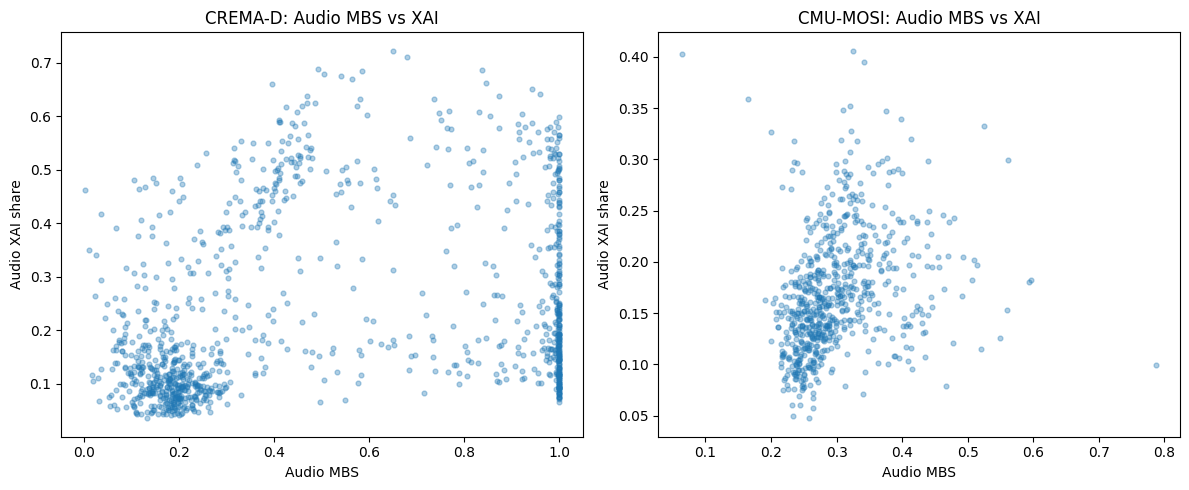

FINAL XAI ↔ MBS CORRELATION RESULTS


,dataset,modality,n,pearson_r,pearson_p,spearman_r,spearman_p,mbs_mean,xai_mean
0,CREMA-D,audio,1065,0.3051,0.0,0.3832,0.0,0.5026,0.2374
1,CREMA-D,visual,1065,0.3051,0.0,0.3830,0.0,0.4974,0.7626
2,CMU-MOSI,text,686,0.4456,0.0,0.5601,0.0,0.4059,0.6487
3,CMU-MOSI,audio,686,0.2800,0.0,0.4340,0.0,0.3001,0.1696
4,CMU-MOSI,vision,686,0.3850,0.0,0.4742,0.0,0.2940,0.1818



Saved:
/content/DL_project/modality_bias/results/xai_mbs_correlation_all_datasets.csv
/content/DL_project/modality_bias/results/xai_mbs_summary_all_datasets.csv
/content/DL_project/modality_bias/results/xai_mbs_scatter_crema_cmu.png

Interpretation:
Pearson measures linear association between MBS and XAI share; Spearman measures monotonic association. These are associations, not causal effects.
MBS was computed independently from unimodal classifier outputs; XAI was computed independently from encoder-level Integrated Gradients.


In [27]:

# ============================================================
# CELL 5 — PEARSON + SPEARMAN CORRELATION + FINAL OUTPUTS
# ============================================================

def correlation_row(
    dataset,
    modality,
    df,
    mbs_col,
    xai_col
):
    x = pd.to_numeric(df[mbs_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[xai_col], errors="coerce").to_numpy()

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        raise ValueError(
            f"Not enough samples for {dataset}/{modality}"
        )

    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)

    return {
        "dataset": dataset,
        "modality": modality,
        "n": int(len(x)),
        "pearson_r": float(pr),
        "pearson_p": float(pp),
        "spearman_r": float(sr),
        "spearman_p": float(sp),
        "mbs_mean": float(x.mean()),
        "xai_mean": float(y.mean())
    }


rows = []

# CREMA-D
for m, mbs_col, xai_col in [
    ("audio", "mbs_audio", "xai_audio"),
    ("visual", "mbs_visual", "xai_visual")
]:
    rows.append(
        correlation_row(
            "CREMA-D",
            m,
            crema_result,
            mbs_col,
            xai_col
        )
    )

# CMU-MOSI
for m, mbs_col, xai_col in [
    ("text", "text_MBS", "xai_text"),
    ("audio", "audio_MBS", "xai_audio"),
    ("vision", "vision_MBS", "xai_vision")
]:
    rows.append(
        correlation_row(
            "CMU-MOSI",
            m,
            cmu_result,
            mbs_col,
            xai_col
        )
    )

correlation_df = pd.DataFrame(rows)

CORR_CSV = RESULTS_DIR / "xai_mbs_correlation_all_datasets.csv"
correlation_df.to_csv(CORR_CSV, index=False)

SUMMARY_CSV = RESULTS_DIR / "xai_mbs_summary_all_datasets.csv"

summary_df = pd.DataFrame([
    {
        "dataset": "CREMA-D",
        "n": len(crema_result),
        "mean_mbs_audio": crema_result.mbs_audio.mean(),
        "mean_mbs_visual": crema_result.mbs_visual.mean(),
        "mean_xai_audio": crema_result.xai_audio.mean(),
        "mean_xai_visual": crema_result.xai_visual.mean()
    },
    {
        "dataset": "CMU-MOSI",
        "n": len(cmu_result),
        "mean_mbs_text": cmu_result.text_MBS.mean(),
        "mean_mbs_audio": cmu_result.audio_MBS.mean(),
        "mean_mbs_vision": cmu_result.vision_MBS.mean(),
        "mean_xai_text": cmu_result.xai_text.mean(),
        "mean_xai_audio": cmu_result.xai_audio.mean(),
        "mean_xai_vision": cmu_result.xai_vision.mean()
    }
])

summary_df.to_csv(SUMMARY_CSV, index=False)


# ------------------------------------------------------------
# Scatter plots
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5)
)

# CREMA
axes[0].scatter(
    crema_result.mbs_audio,
    crema_result.xai_audio,
    alpha=0.35,
    s=12
)
axes[0].set_xlabel("Audio MBS")
axes[0].set_ylabel("Audio XAI share")
axes[0].set_title("CREMA-D: Audio MBS vs XAI")

# CMU text
axes[1].scatter(
    cmu_result.audio_MBS,
    cmu_result.xai_audio,
    alpha=0.35,
    s=12
)
axes[1].set_xlabel("Audio MBS")
axes[1].set_ylabel("Audio XAI share")
axes[1].set_title("CMU-MOSI: Audio MBS vs XAI")

plt.tight_layout()

PLOT = RESULTS_DIR / "xai_mbs_scatter_crema_cmu.png"
plt.savefig(PLOT, dpi=180, bbox_inches="tight")
plt.show()


print("=" * 75)
print("FINAL XAI ↔ MBS CORRELATION RESULTS")
print("=" * 75)

display(
    correlation_df.round(4)
)

print("\nSaved:")
print(CORR_CSV)
print(SUMMARY_CSV)
print(PLOT)

# ------------------------------------------------------------
# Scientific interpretation helper
# ------------------------------------------------------------
print("\nInterpretation:")
print(
    "Pearson measures linear association between MBS and XAI share; "
    "Spearman measures monotonic association. These are associations, "
    "not causal effects."
)
print(
    "MBS was computed independently from unimodal classifier outputs; "
    "XAI was computed independently from encoder-level Integrated Gradients."
)
